<a href="https://colab.research.google.com/github/minoshim/Num_Analysis/blob/main/FDS/Py/Diff/fds_diff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulation end at t = 0.006000


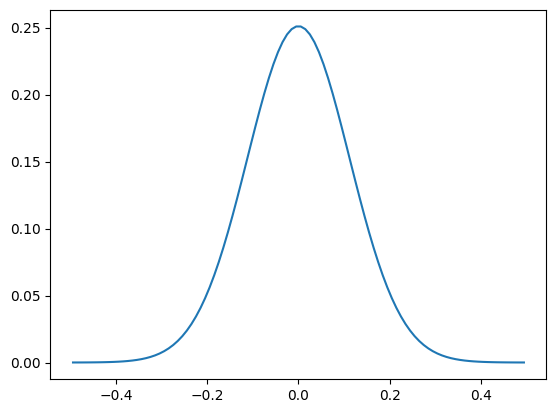

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# User-set parameters
## Spatial grid
xoff=2
xmesh=100
nx=xmesh+2*xoff
## Domain size, Diffusion coefficient, CFL number
lx=1.0
kx=1.0
cfl=0.6
## Simulation time
tmax=0.006
# End of user-set parameters

# Grid width
dx=lx/xmesh
dt=np.abs(cfl*dx*dx/kx)
# Variables
x=np.zeros(nx)
f=np.zeros(nx)

# Functions
def init(x,f):                  # Initialize
    nx=len(f)
    i=np.arange(nx)
    x[:]=(i+0.5-xoff)*dx-0.5*lx
    f[:]=np.exp(-(x[:]*x[:])/(16*dx*dx))

def bc1d(f,xoff,dnx=0):         # Boundary condition
    nx = len(f)
    if dnx == 0:
        f[:xoff] = f[nx - 2*xoff : nx - xoff]
        f[nx - xoff:] = f[xoff : 2*xoff]
    elif abs(dnx) == 1:
        f[:xoff] = dnx * f[xoff : 2*xoff][::-1]
        f[nx - xoff:] = dnx * f[nx - 2*xoff : nx - xoff][::-1]

def dif1de(f,kx,dt,dx,xoff):    # Explicit scheme for diffusion
    nx=len(f)
    dd=kx*dt/(dx*dx)
    df=np.zeros_like(f)
    df[1:]=f[1:]-f[:-1]
    f[xoff:nx-xoff]+=dd*(df[xoff+1:nx-xoff+1]-df[xoff:nx-xoff])

def dif1di(f,kx,dt,dx,xoff,alpha=1.0):    # Implicit scheme for diffusion
    from scipy.linalg import solve_banded
    nx=len(f)
    dd=kx*dt/(dx*dx)
    add=alpha*dd
    bdd=(1.0-alpha)*dd
    ab=np.zeros((3,nx))
    d=np.zeros(nx)
    ab[0,1:]=-add
    ab[1,:]=1.0+2.0*add
    ab[2,:-1]=-add
    d[1:-1]=(1.0-2.0*bdd)*f[1:-1]+bdd*(f[2:]+f[:-2])
    f[:]=solve_banded((1,1),ab,d)

def main(t,tmax):
    while(t < tmax):
        bc1d(f,xoff,1)
        dif1di(f,kx,dt,dx,xoff)
        t += dt
    return t

init(x,f)
t=main(0,tmax)
print(f"Simulation end at t = {t:.6f}")
plt.plot(x[xoff:-xoff],f[xoff:-xoff])
plt.show()